<a href="https://colab.research.google.com/github/aothmanboahen/Financial_Fraud_Detection_Systems/blob/main/02_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**EDA (FRAUD PATTERNS)**
*“Understand What Makes a Transaction Suspicious”*


In [ ]:
import pandas as pd

df = pd.read_csv("/content/datarawcreditcard.csv")

In [ ]:
df = df.dropna(subset=["Class"])
df["Class"] = df["Class"].astype(int)

TARGET DISTRIBUTION (RECAP)

In [ ]:
df["Class"].value_counts(normalize=True)

,proportion
Class,
0,0.996889
1,0.003111


TRANSACTION AMOUNT VS FRAUD

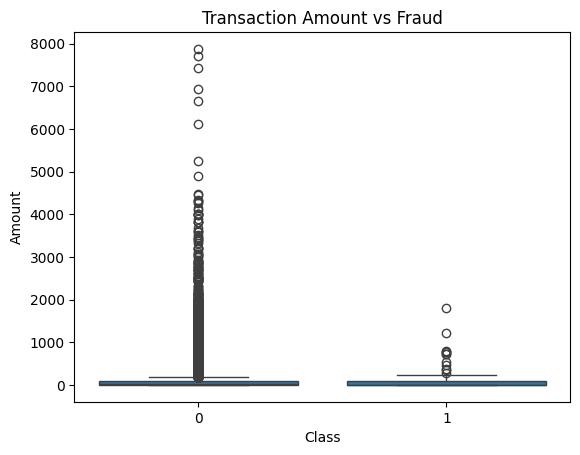

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Transaction Amount vs Fraud")
plt.show()

DEEPER VIEW

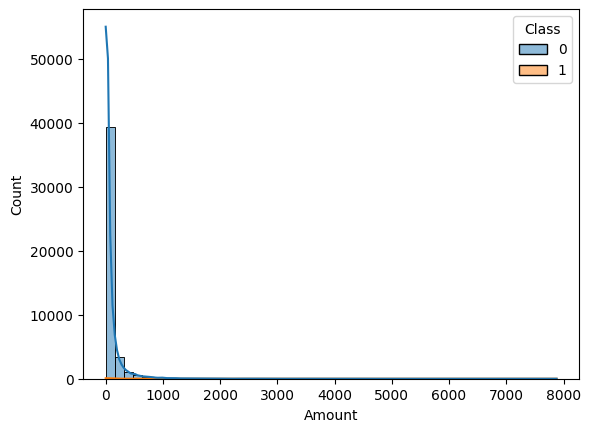

In [ ]:
sns.histplot(data=df, x="Amount", hue="Class", bins=50, kde=True)
plt.show()

TIME-BASED PATTERNS

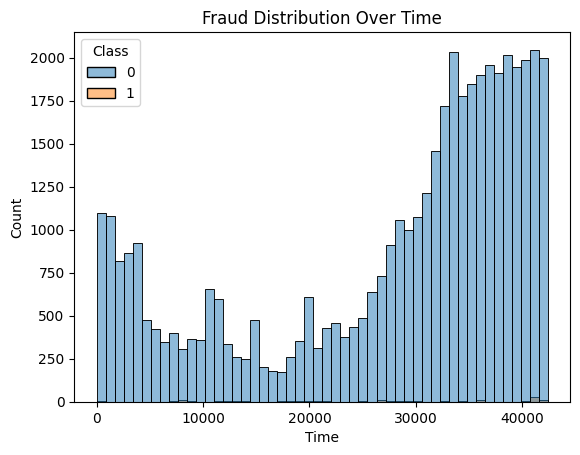

In [ ]:
sns.histplot(data=df, x="Time", hue="Class", bins=50)
plt.title("Fraud Distribution Over Time")
plt.show()

CORRELATION ANALYSIS

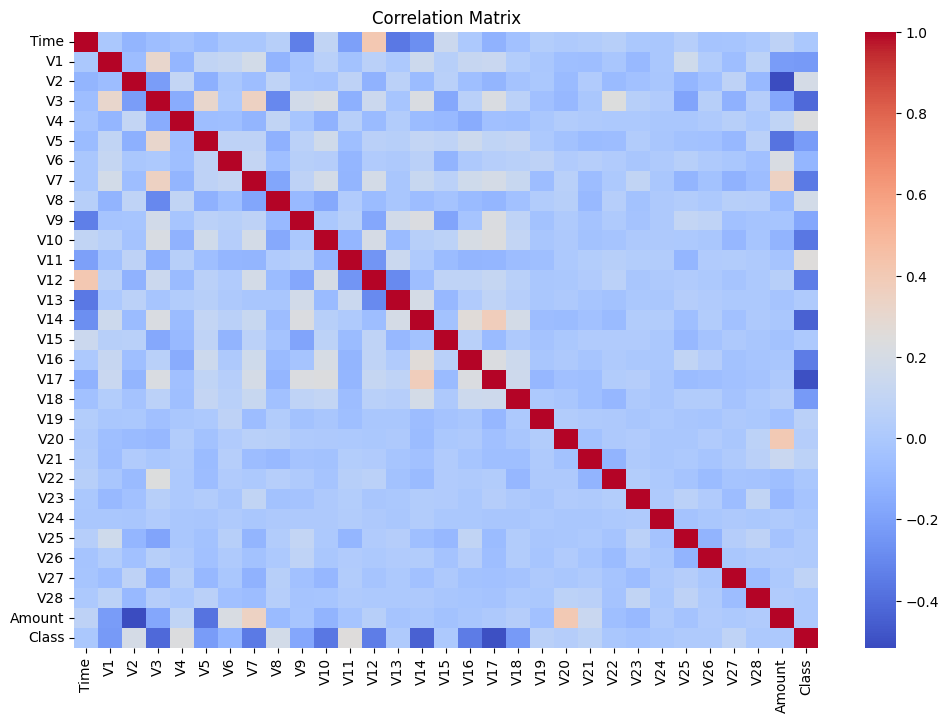

In [ ]:
corr = df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

TOP CORRELATED FEATURES WITH FRAUD

In [ ]:
corr_with_target = corr["Class"].sort_values(ascending=False)
print(corr_with_target.head(10))
print(corr_with_target.tail(10))

Class    1.000000
V11      0.252337
V4       0.233830
V2       0.193251
V8       0.177593
V27      0.084770
V21      0.070517
V19      0.063464
V20      0.034696
V26      0.015730
Name: Class, dtype: float64
V5    -0.221692
V1    -0.226062
V18   -0.231034
V12   -0.343063
V16   -0.345591
V7    -0.354988
V10   -0.365220
V3    -0.414939
V14   -0.444689
V17   -0.498560
Name: Class, dtype: float64


VISUALIZE IMPORTANT FEATURES

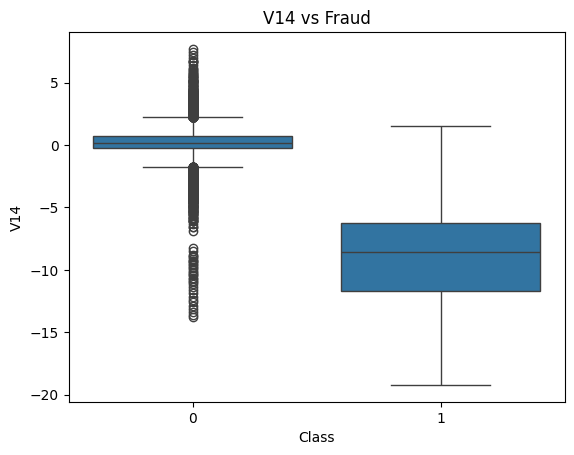

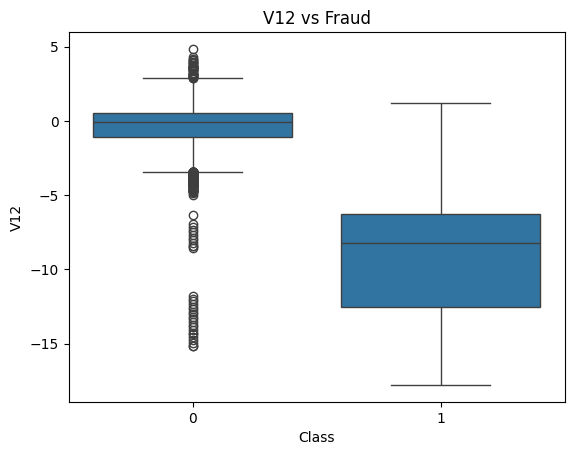

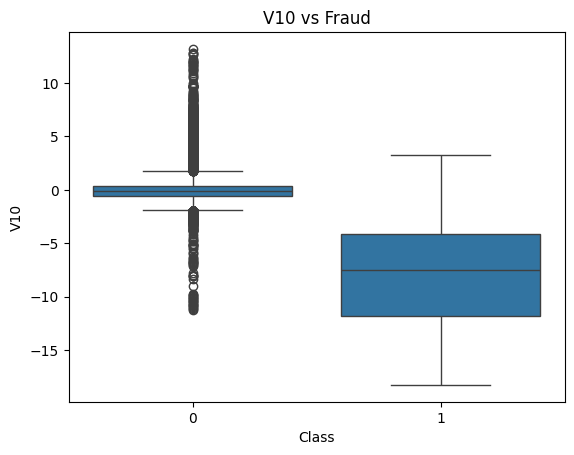

In [ ]:
important_features = ["V14", "V12", "V10"]  # example

for feature in important_features:
    sns.boxplot(x="Class", y=feature, data=df)
    plt.title(f"{feature} vs Fraud")
    plt.show()

OUTLIER DETECTION

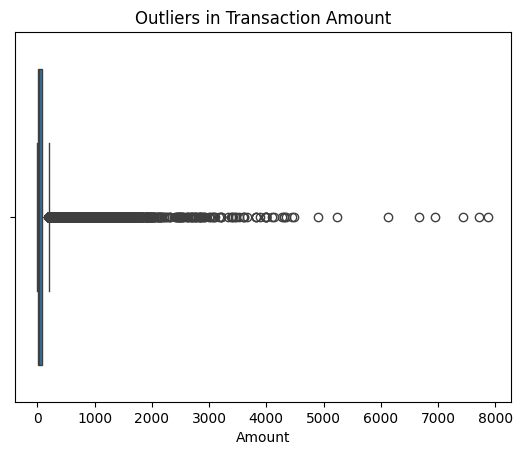

In [ ]:
sns.boxplot(x=df["Amount"])
plt.title("Outliers in Transaction Amount")
plt.show()

FRAUD RATIO BY AMOUNT RANGE (POWER MOVE)

/tmp/ipykernel_3159/1414890338.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_rate = df.groupby("Amount_bin")["Class"].mean()


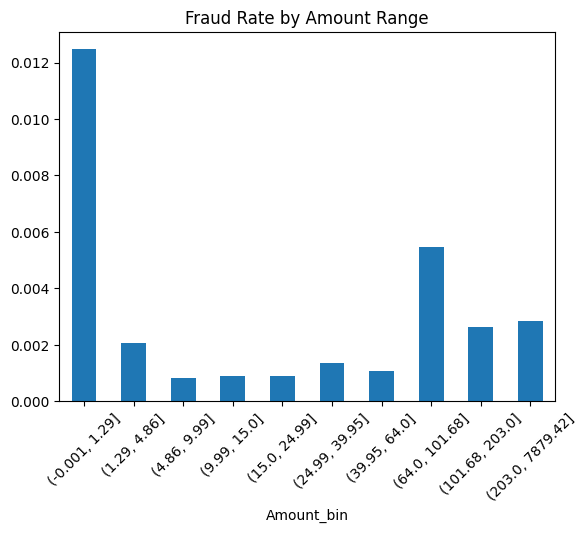

In [ ]:
df["Amount_bin"] = pd.qcut(df["Amount"], q=10)

fraud_rate = df.groupby("Amount_bin")["Class"].mean()

fraud_rate.plot(kind="bar")
plt.title("Fraud Rate by Amount Range")
plt.xticks(rotation=45)
plt.show()

### Key Fraud Insights

1. Fraud transactions are extremely rare (~0.2%).
2. Fraud is not always associated with high transaction amounts.
3. Certain features (e.g., V14, V12, V10) strongly differentiate fraud.
4. Fraud transactions behave like anomalies (outliers).
5. Specific transaction ranges show higher fraud rates.